Found 41 files between 10:23 and 10:28.


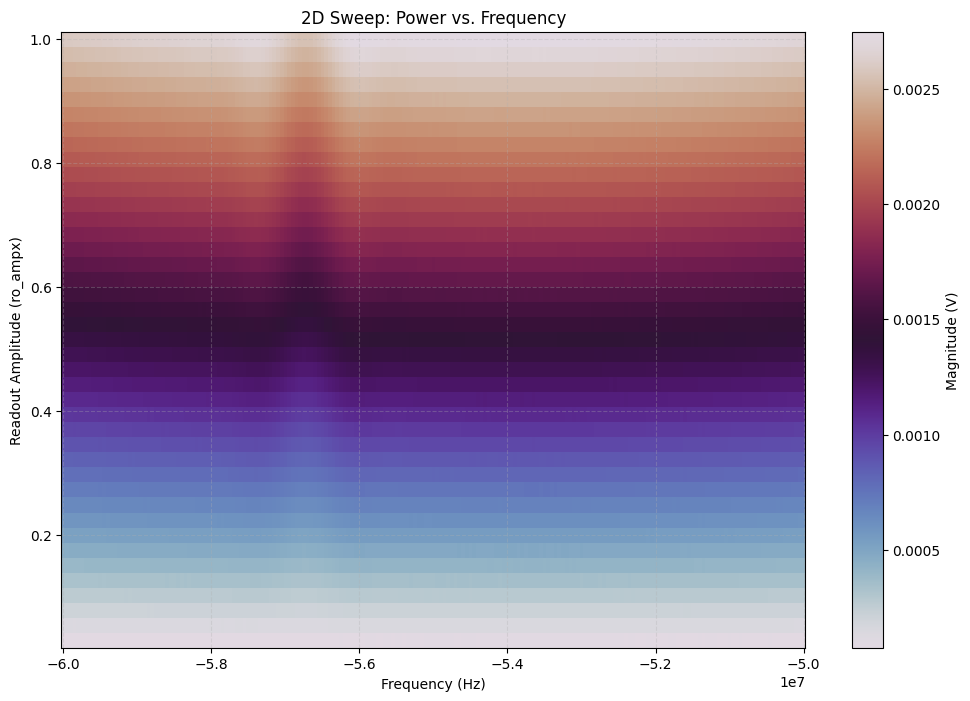

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
#env: .venv(python 3.10.11)
# 1. Define the folder and time range
folder_path = "C:/Users/qcrew/Desktop/Juncheng/victoria/data/2026-08-08/" # Update to your path

# --- TIME FILTER SETTINGS ---
start_time = (10, 23)
end_time = (10, 28)

def extract_time(filename):
    parts = filename.split("-")
    return (int(parts[0]), int(parts[1]))

files = []
for f in os.listdir(folder_path):
    if f.endswith(".hdf5") and "RRSpec_amp_sweep" in f:
        file_time = extract_time(f)
        if start_time <= file_time <= end_time:
            files.append(os.path.join(folder_path, f))

files.sort()
print(f"Found {len(files)} files between {start_time[0]}:{start_time[1]:02d} and {end_time[0]}:{end_time[1]:02d}.")

# 2. Define Amplitude axis externally (since it's NOT in the HDF5)
# REPLACE these with the actual amplitude range of your sweep
start_amp = 0.03  # e.g., 0.0 A.U.
stop_amp = 1.0   # e.g., 1.0 A.U.
expected_amps = np.linspace(start=start_amp, stop=stop_amp, num=len(files))

all_mags = []
freq_axis = None
valid_amps = [] # Keep track of amplitudes for files that are actually valid

# 3. Extract the data
for amp, path in zip(expected_amps, files):
    try:
        with h5py.File(path, "r") as f:
            # Extract the built-in resonator frequency (X-axis) just once
            if freq_axis is None:
                if "resonator_frequency" in f:
                    freq_data = f["resonator_frequency"]
                    if freq_data.shape: # If it has actual array data
                        freq_axis = np.array(freq_data[()]).flatten()
                    else: # If it relies on attributes (start, stop, num)
                        start = freq_data.attrs.get('start', 0)
                        stop = freq_data.attrs.get('stop', 0)
                        num = freq_data.attrs.get('num', 1)
                        freq_axis = np.linspace(start, stop, num)
                    expected_length = len(freq_axis)
            
            # Extract Magnitude directly from the file
            mag = f["Magnitude"][()]
            
            # Average over the repetition 'N' dimension if it exists
            if mag.ndim > 1:
                mag = np.mean(mag, axis=0)
                
            # STRICT CHECK: Ensure this file's magnitude array matches the frequency array length
            if freq_axis is not None and len(mag) != expected_length:
                print(f"Skipping {os.path.basename(path)}: Shape mismatch. Expected {expected_length}, got {len(mag)}")
                continue
                
            # Pair the scalar amplitude with its 1D magnitude array
            all_mags.append(mag)
            valid_amps.append(amp)
            
    except Exception as e:
        print(f"Skipping {os.path.basename(path)} due to error: {e}")

# 4. Generate the 2D Plot
if all_mags:
    plt.figure(figsize=(12, 8))
    
    # X is Frequency (from file), Y is Amplitude (from linspace)
    X, Y = np.meshgrid(freq_axis, valid_amps)
    Z = np.array(all_mags)
    
    # Plot using pcolormesh
    # Z does not need to be transposed here because it's naturally built as (amps, freqs)
    mesh = plt.pcolormesh(X, Y, Z, shading='auto', cmap='twilight')
    
    plt.colorbar(mesh, label='Magnitude (V)')
    plt.xlabel('Frequency (Hz)') # Adjust if you need to scale the freq_axis to MHz/GHz
    plt.ylabel('Readout Amplitude (ro_ampx)')
    plt.title('2D Sweep: Power vs. Frequency')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()
else:
    print("No valid data found to plot!")